Using cache found in C:\Users\Nil/.cache\torch\hub\ultralytics_yolov5_master


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Nil\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command '"C:\Users\Nil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe" -m pip install --no-cache-dir "urllib3>=2.6.0 ; python_version > "3.8"" ' returned non-zero exit status 2.
WARNING Retry 2/2 failed: Command '"C:\Users\Nil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe" -m pip install --no-cache-dir "urllib3>=2.6.0 ; python_version > "3.8"" ' returned non-zero exit status 2.
WARNING requirements:  Command '"C:\Users\Nil\A

YOLOv5  2026-5-3 Python-3.13.13 torch-2.7.0+cpu CPU

100%|██████████| 14.1M/14.1M [00:03<00:00, 4.87MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
C:\Users\Nil/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


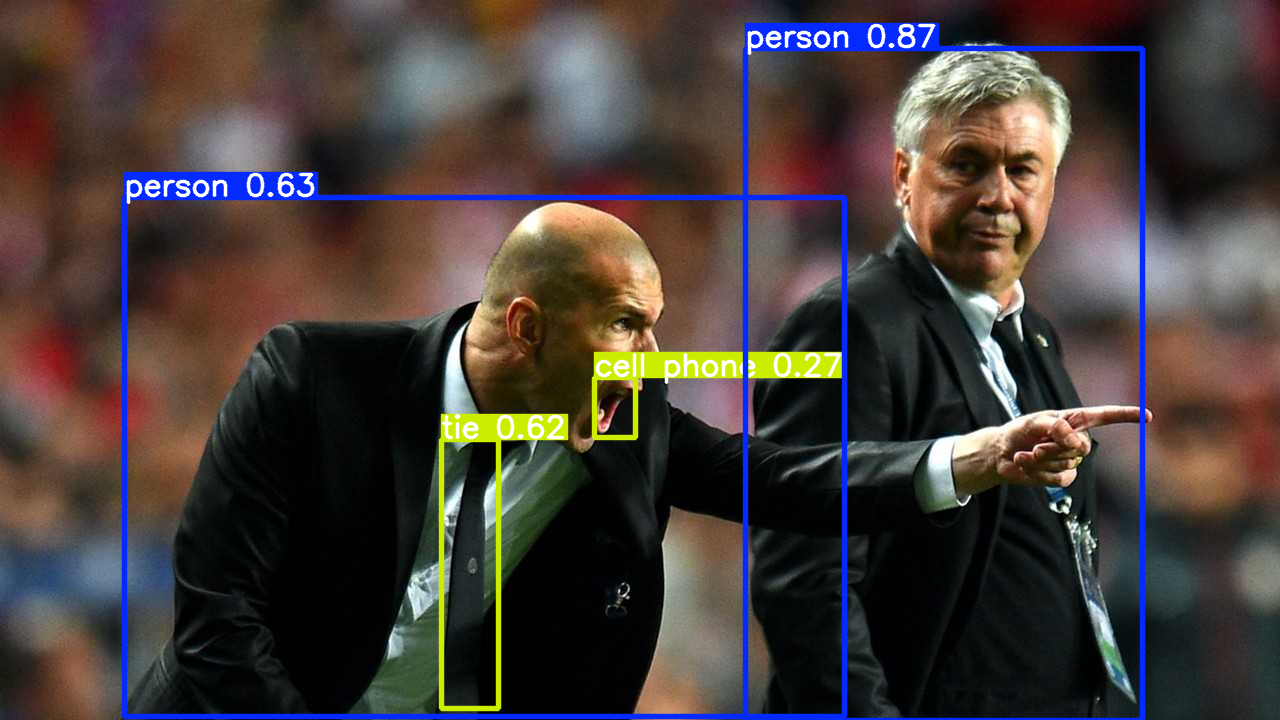

In [2]:
import torch

# Cargar modelo YOLOv5 preentrenado
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# Imagen de prueba
img_url = 'https://ultralytics.com/images/zidane.jpg'
results = model(img_url)

# Mostrar resultados
results.show()


In [ ]:
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import requests
from io import BytesIO

# Descargar imagen
url = 'https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg'
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Modelo
fasterrcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
fasterrcnn.eval()

# Transformar imagen y predecir
x = [F.to_tensor(img)]
preds = fasterrcnn(x)

print(preds[0]['labels'][:5])
print(preds[0]['boxes'][:5])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Nil/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:25<00:00, 6.58MB/s] 


tensor([18, 18, 18, 18, 16])
tensor([[ 51.59562,  98.06207, 370.83432, 403.05878],
        [ 44.02195, 118.38935, 194.14349, 214.35991],
        [ 51.80661, 112.18507, 359.52097, 266.99585],
        [ 75.80132, 108.86311, 264.66913, 229.38338],
        [137.82486, 101.31404, 364.09186, 273.81610]], grad_fn=<SliceBackward0>)


In [5]:
import cv2

cap = cv2.VideoCapture(0)  # 0 para webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Detección
    results = model(frame)

    # Renderizar con bounding boxes
    annotated = results.render()[0]

    cv2.imshow('Detección en tiempo real', annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
